# Fake.br: experimento Local Outlier Factor para desvio linguístico

Notebook independente derivado do protocolo do Isolation Forest. Os quatro detectores LOF
aprendem somente com notícias **True**; labels Fake aparecem apenas na seleção assistida por
validação e na avaliação do teste histórico. `anomalyScore` é um sinal de desvio linguístico,
não uma probabilidade de falsidade e não comprova que uma notícia seja falsa.

**Recorte implementado:** pipelines LOF fechados com `n_neighbors` 10, 20, 40 e 80,
`novelty=True`, diagnóstico do fit separado da pontuação de novidade, seleção ROC-AUC → AP →
menor `n_neighbors` na validação, corte q95 calibrado somente em True-validation, controles
Isolation Forest e One-Class SVM congelado, avaliação por ID, casos extremos e transições.


## 1. Imports e configuração do ambiente

Execute esta célula em um kernel limpo. No Colab, as bibliotecas `numpy`, `pandas`, `scikit-learn` e `matplotlib` normalmente já estão disponíveis; se o ambiente solicitar, instale-as antes de executar todas as células.

In [1]:
import hashlib
import json
import os
import platform
import re
import time
import unicodedata
from importlib.metadata import version
from itertools import combinations
from pathlib import Path
from urllib.request import urlopen
from zipfile import ZipFile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

In [2]:
RANDOM_STATE = 42
pd.set_option("display.max_rows", 80)
pd.set_option("display.max_columns", 20)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.2})
print("Python:", platform.python_version())
print({name: version(name) for name in ["numpy", "pandas", "scikit-learn", "matplotlib", "ipykernel"]})
BASE_NOTEBOOK_SHA256 = "25ff9d35c233c9bd6067ce0ebcf14bc78a077659f5c769a15b8f4486bd542d79"
OCSVM_NOTEBOOK_SHA256 = "87660b32622b7a0a4f9dfc0c0458b62983215228fe6d01e31729b6e48a2eaddb"
EXPERIMENT_KEY = "local-outlier-factor-core-confirmatory"


Python: 3.14.2
{'numpy': '2.5.3', 'pandas': '3.0.6', 'scikit-learn': '1.9.1', 'matplotlib': '3.11.2', 'ipykernel': '7.3.0'}


## 2. Carregamento dos dados

Mesmo ZIP e revisão fixa do notebook original. Textos completos e metadados são
carregados para auditoria; o truncamento acontece ANTES da extração usada nos
modelos. Nenhuma notícia é excluída por comprimento.

In [3]:
CORPUS_REVISION = "780f5516c4ae070761632d98ac3368f3ded09d35"
CORPUS_URL = f"https://codeload.github.com/roneysco/Fake.br-Corpus/zip/{CORPUS_REVISION}"
project_folder = Path.cwd()
data_folder = project_folder / "data"
data_folder.mkdir(exist_ok=True)
archive_path = data_folder / f"Fake.br-Corpus-{CORPUS_REVISION}.zip"

if not archive_path.exists():
    temporary_path = archive_path.with_suffix(".download")
    with urlopen(CORPUS_URL, timeout=120) as response, temporary_path.open("wb") as target:
        while chunk := response.read(1024 * 1024):
            target.write(chunk)
    with ZipFile(temporary_path) as archive:
        assert archive.testzip() is None, "ZIP corrompido; refaça o download."
    temporary_path.replace(archive_path)

print("Corpus revision:", CORPUS_REVISION)
print("Archive SHA256:", hashlib.sha256(archive_path.read_bytes()).hexdigest())

Corpus revision: 780f5516c4ae070761632d98ac3368f3ded09d35
Archive SHA256: be91c188f621424017bd79a0f33528dcc27f8a6151adb2bcb899c17719eb4090


In [4]:
metadata_columns = [
    "autor", "link", "categoria", "data_publicacao",
    "num_tokens", "num_palavras", "num_types", "num_links", "num_maiusculas",
    "num_verbos", "num_verbos_subj_imp", "num_substantivos", "num_adjetivos",
    "num_adverbios", "num_verbos_modais", "num_pron_1_2_sing", "num_pron_1_plural",
    "num_pronomes", "pausalidade", "num_caracteres", "tam_medio_sentenca",
    "tam_medio_palavra", "pct_erros_ortograficos", "emotividade", "diversidade",
]

In [5]:
def load_news_texts(archive, folder, label):
    records = []
    for name in sorted(archive.namelist()):
        if f"/full_texts/{folder}/" not in name or not name.endswith(".txt"):
            continue
        article_id = Path(name).stem + ("t" if label == 0 else "")
        records.append({
            "id": article_id, "text": archive.read(name).decode("utf-8"),
            "label": label, "sourceClass": folder,
        })
    assert records, f"Nenhum texto encontrado em {folder}"
    return pd.DataFrame(records)


def load_news_metadata(archive, folder, label):
    records = []
    for name in sorted(archive.namelist()):
        if f"/full_texts/{folder}-meta-information/" not in name or not name.endswith("-meta.txt"):
            continue
        values = [line.strip() for line in archive.read(name).decode("utf-8").splitlines()]
        assert len(values) == len(metadata_columns), f"Esquema inesperado em {name}: {len(values)} linhas"
        article_id = Path(name).name.removesuffix("-meta.txt") + ("t" if label == 0 else "")
        records.append({**dict(zip(metadata_columns, values)), "id": article_id, "metadataLabel": label})
    assert records, f"Nenhum metadado encontrado em {folder}"
    return pd.DataFrame(records)

In [6]:
with ZipFile(archive_path) as archive:
    texts_frame = pd.concat([
        load_news_texts(archive, "fake", 1), load_news_texts(archive, "true", 0),
    ], ignore_index=True)
    metadata_frame = pd.concat([
        load_news_metadata(archive, "fake", 1), load_news_metadata(archive, "true", 0),
    ], ignore_index=True)

assert texts_frame["id"].is_unique and metadata_frame["id"].is_unique
assert set(texts_frame["id"]) == set(metadata_frame["id"]), "Texto/metadados sem correspondência"
news_frame = texts_frame.merge(metadata_frame, on="id", validate="one_to_one", indicator=True)
assert news_frame["_merge"].eq("both").all()
assert news_frame["label"].eq(news_frame["metadataLabel"]).all()
news_frame = news_frame.drop(columns=["_merge", "metadataLabel"])
assert news_frame["text"].str.strip().ne("").all()
print(f"{len(news_frame):,} notícias carregadas; textos e metadados correspondem 1:1.")

7,200 notícias carregadas; textos e metadados correspondem 1:1.


## 3. Contrato dos labels

**0 = True; 1 = Fake.** O rótulo forma as partições e permite avaliação externa.
Não entra como feature. A origem nas pastas também é verificada.

In [7]:
label_names = {0: "True", 1: "Fake"}
assert label_names == {0: "True", 1: "Fake"}
assert set(news_frame["label"].unique()) == {0, 1}
assert news_frame.loc[news_frame["label"].eq(0), "sourceClass"].eq("true").all()
assert news_frame.loc[news_frame["label"].eq(1), "sourceClass"].eq("fake").all()
display(news_frame.groupby(["label", "sourceClass"]).size().rename("newsCount").to_frame())

,,newsCount
label,sourceClass,
0,true,3600
1,fake,3600


## 4. Preparação dos metadados

Preservamos todos os campos brutos em `raw_news_frame` e todas as contagens numéricas
em `news_frame`. Valores não numéricos viram NaN com contagem explícita; nenhum
ausente é preenchido antes do treino. `tem_autor` segue a lógica do original:
ausência para string vazia, `None`, `none` ou `NULL`. Não é uma medida de credibilidade.

In [8]:
raw_news_frame = news_frame.copy(deep=True)
numeric_metadata_columns = metadata_columns[4:]
converted_metadata = news_frame[numeric_metadata_columns].apply(pd.to_numeric, errors="coerce")
conversion_missing = converted_metadata.isna().sum().rename("missingAfterNumericConversion")
display(conversion_missing.to_frame())
news_frame[numeric_metadata_columns] = converted_metadata
news_frame["tem_autor"] = (~news_frame["autor"].fillna("").astype(str).str.strip().isin(
    ["", "None", "none", "NULL"]
)).astype(int)

,missingAfterNumericConversion
num_tokens,0
num_palavras,0
num_types,0
num_links,1393
num_maiusculas,0
num_verbos,0
num_verbos_subj_imp,0
num_substantivos,0
num_adjetivos,0
num_adverbios,0


## 5. Extração no texto efetivamente utilizado

Normalização Unicode NFKC, remoção do BOM inicial e primeiros CHARACTER_LIMIT
caracteres, incluindo espaços/pontuação. Textos menores permanecem menores, sem
preenchimento. O corte pode dividir palavras/frases. Palavras são sequências de
letras com hífen/apóstrofo interno; tokens também incluem números e pontuação.
Tipos são palavras distintas ignorando caixa. TTR = tipos/tokens; diversidade =
tipos/palavras. Maiúsculas conta palavras totalmente maiúsculas com mais de uma
letra. Links são URLs http(s) presentes no corpo. Estas definições explícitas
não pretendem reproduzir o extrator desconhecido dos metadados históricos.

As demais contagens linguísticas são marcadas ausentes na cópia de features,
não imputadas nem selecionadas pelo modelo; originais ficam em `raw_news_frame` e
`news_frame`. Autor permanece como metadado válido da notícia inteira.

In [9]:
def calculate_ratio(numerator, denominator):
    numerator = pd.to_numeric(numerator, errors="coerce").astype(float)
    denominator = pd.to_numeric(denominator, errors="coerce").astype(float)
    safe_denominator = denominator.where(denominator.gt(0) & np.isfinite(denominator))
    return numerator.div(safe_denominator).replace([np.inf, -np.inf], np.nan)

In [10]:
CHARACTER_LIMIT = 300
numeric_metadata_columns = metadata_columns[4:]
anomaly_columns = ["tem_autor", "typeTokenRatio", "linkDensity", "punctuationDensity", "uppercaseRatio", "diversidade"]
word_pattern = re.compile(r"[^\W\d_]+(?:['’\-][^\W\d_]+)*", re.UNICODE)
token_pattern = re.compile(r"[^\W\d_]+(?:['’\-][^\W\d_]+)*|\d+(?:[.,]\d+)*|[^\w\s]", re.UNICODE)


def measure_text(text, character_limit):
    normalized = unicodedata.normalize("NFKC", text).lstrip("\ufeff")
    if character_limit is not None:
        if not isinstance(character_limit, int) or character_limit < 1:
            raise ValueError("Limite deve ser inteiro positivo ou None.")
        normalized = normalized[:character_limit]
    words = word_pattern.findall(normalized)
    return {"text": normalized, "num_palavras": len(words),
            "num_tokens": len(token_pattern.findall(normalized)),
            "num_types": len({word.casefold() for word in words}),
            "num_links": len(re.findall(r"https?://\S+", normalized, flags=re.IGNORECASE)),
            "num_maiusculas": sum(word.isupper() and len(word) > 1 for word in words),
            "num_caracteres": len(normalized)}


def extract_anomaly_features(news_frame, character_limit=CHARACTER_LIMIT):
    features_frame = news_frame.copy(deep=True)
    features_frame["num_palavras_original"] = news_frame["num_palavras"]
    features_frame["text_original"] = news_frame["text"]
    features_frame[numeric_metadata_columns] = np.nan
    measurements = pd.DataFrame([measure_text(text, character_limit) for text in news_frame["text"]], index=news_frame.index)
    for column in measurements:
        features_frame[column] = measurements[column]
    features_frame["typeTokenRatio"] = calculate_ratio(features_frame["num_types"], features_frame["num_tokens"])
    features_frame["diversidade"] = calculate_ratio(features_frame["num_types"], features_frame["num_palavras"])
    features_frame["linkDensity"] = calculate_ratio(features_frame["num_links"], features_frame["num_palavras"])
    features_frame["punctuationDensity"] = calculate_ratio(features_frame["num_tokens"] - features_frame["num_palavras"], features_frame["num_tokens"])
    features_frame["uppercaseRatio"] = calculate_ratio(features_frame["num_maiusculas"], features_frame["num_palavras"])
    return features_frame

In [11]:
features_frame = extract_anomaly_features(news_frame)
features_frame[anomaly_columns] = features_frame[anomaly_columns].replace([np.inf, -np.inf], np.nan)
display(features_frame[anomaly_columns].isna().sum().rename("missingCount").to_frame())
print("Limite de caracteres:", CHARACTER_LIMIT)
display(features_frame.groupby("label")[["num_palavras_original", "num_palavras", "num_caracteres"]].agg(["min", "median", "max"]))
print("Textos menores que o limite:", int(features_frame["num_caracteres"].lt(CHARACTER_LIMIT).sum()))

,missingCount
tem_autor,0
typeTokenRatio,0
linkDensity,0
punctuationDensity,0
uppercaseRatio,0
diversidade,0


Limite de caracteres: 300


num_palavras_original              num_palavras             \
                        min median   max          min median max   
label                                                              
0                        20  922.0  7588           19   47.0  60   
1                         9  157.0  2294            8   48.0  64   

      num_caracteres              
                 min median  max  
label                             
0                114  300.0  300  
1                 46  300.0  300

Textos menores que o limite: 99


## 6. Verificações de consistência

As seis features utilizam o prefixo; a presença de autor vem dos metadados.
Contagens originais ficam preservadas para auditoria e não alimentam o modelo.

In [12]:
assert "num_palavras" not in anomaly_columns
assert "label" not in anomaly_columns and "id" not in anomaly_columns
assert len(anomaly_columns) == len(set(anomaly_columns)) == 6
assert features_frame["id"].is_unique
assert features_frame["num_caracteres"].le(CHARACTER_LIMIT).all()
assert features_frame["num_palavras_original"].equals(news_frame["num_palavras"])
assert features_frame["num_verbos"].isna().all()
assert not np.isinf(features_frame[anomaly_columns].to_numpy(dtype=float)).any()
assert measure_text("casa " * 100, 300)["num_palavras"] == 60
assert measure_text("casa " * 100, 300)["num_caracteres"] == 300
print("Contagens do prefixo verificadas; num_palavras não entra no treinamento.")

Contagens do prefixo verificadas; num_palavras não entra no treinamento.


## 7. Análise estatística

Estatísticas descritivas por label, sem substituir vetores individuais por médias.
Esta inspeção do corpus completo atende ao protocolo exploratório: não usamos
seus resultados para selecionar features, ajustar hiperparâmetros ou threshold.
Qualquer escolha futura guiada por estes resultados exige nova avaliação independente.
Correlações de Pearson com comprimento são mostradas no total e por classe para
evitar confundir efeitos de classe e de tamanho. NaN em correlação pode indicar
feature constante. Mantemos as seis features recalculadas, inclusive possíveis redundâncias.

In [13]:
statistics_records = []
for label, group in features_frame.groupby("label", sort=True):
    for feature in anomaly_columns:
        values = group[feature]
        q1, q3 = values.quantile([0.25, 0.75])
        statistics_records.append({
            "label": label, "class": label_names[label], "feature": feature,
            "count": values.count(), "mean": values.mean(), "median": values.median(),
            "std": values.std(), "min": values.min(), "Q1": q1, "Q3": q3,
            "IQR": q3 - q1, "max": values.max(), "missingCount": values.isna().sum(),
        })
feature_statistics = pd.DataFrame(statistics_records).set_index(["label", "class", "feature"])
display(feature_statistics)

length_columns = ["num_palavras", "num_tokens"]
length_correlations = pd.concat({
    name: group[anomaly_columns + length_columns].corr().loc[anomaly_columns, length_columns]
    for name, group in [
        ("All", features_frame),
        ("True (0)", features_frame.loc[features_frame["label"].eq(0)]),
        ("Fake (1)", features_frame.loc[features_frame["label"].eq(1)]),
    ]
}, names=["group", "feature"])
display(length_correlations)
feature_correlations = features_frame[anomaly_columns].corr()
display(feature_correlations.round(3))
display(length_correlations.xs("typeTokenRatio", level="feature"))
print("Pearson TTR vs diversidade:", feature_correlations.loc["typeTokenRatio", "diversidade"])

count      mean    median       std       min  \
label class feature                                                             
0     True  tem_autor            3600  0.979722  1.000000  0.140968  0.000000   
            typeTokenRatio       3600  0.698048  0.701754  0.068560  0.358974   
            linkDensity          3600  0.000000  0.000000  0.000000  0.000000   
            punctuationDensity   3600  0.145714  0.142857  0.048265  0.000000   
            uppercaseRatio       3600  0.019995  0.020000  0.023448  0.000000   
            diversidade          3600  0.817017  0.822222  0.065109  0.551020   
1     Fake  tem_autor            3600  0.020000  0.000000  0.140019  0.000000   
            typeTokenRatio       3600  0.664573  0.666667  0.066960  0.413333   
            linkDensity          3600  0.000000  0.000000  0.000000  0.000000   
            punctuationDensity   3600  0.167808  0.166667  0.056673  0.035714   
            uppercaseRatio       3600  0.022792  0.019608  0.032375  0.000000   
            diversidade          3600  0.799228  0.800000  0.067613  0.545455   

                                      Q1        Q3       IQR       max  \
label class feature                                                      
0     True  tem_autor           1.000000  1.000000  0.000000  1.000000   
            typeTokenRatio      0.655172  0.745455  0.090282  0.921569   
            linkDensity         0.000000  0.000000  0.000000  0.000000   
            punctuationDensity  0.111111  0.175439  0.064327  0.384615   
            uppercaseRatio      0.000000  0.025000  0.025000  0.315789   
            diversidade         0.777778  0.862745  0.084967  1.000000   
1     Fake  tem_autor           0.000000  0.000000  0.000000  1.000000   
            typeTokenRatio      0.621212  0.707095  0.085883  0.900000   
            linkDensity         0.000000  0.000000  0.000000  0.000000   
            punctuationDensity  0.127273  0.203390  0.076117  0.470588   
            uppercaseRatio      0.000000  0.039216  0.039216  0.420000   
            diversidade         0.755102  0.844444  0.089342  1.000000   

                                missingCount  
label class feature                           
0     True  tem_autor                      0  
            typeTokenRatio                 0  
            linkDensity                    0  
            punctuationDensity             0  
            uppercaseRatio                 0  
            diversidade                    0  
1     Fake  tem_autor                      0  
            typeTokenRatio                 0  
            linkDensity                    0  
            punctuationDensity             0  
            uppercaseRatio                 0  
            diversidade                    0

num_palavras  num_tokens
group    feature                                     
All      tem_autor              -0.016428   -0.158099
         typeTokenRatio         -0.107702   -0.485101
         linkDensity                  NaN         NaN
         punctuationDensity     -0.234614    0.436514
         uppercaseRatio         -0.029622    0.019670
         diversidade            -0.323344   -0.273850
True (0) tem_autor               0.023761    0.025026
         typeTokenRatio         -0.068439   -0.500045
         linkDensity                  NaN         NaN
         punctuationDensity     -0.241752    0.528841
         uppercaseRatio         -0.064469    0.010045
         diversidade            -0.255571   -0.245689
Fake (1) tem_autor               0.019447   -0.078203
         typeTokenRatio         -0.133990   -0.463896
         linkDensity                  NaN         NaN
         punctuationDensity     -0.249768    0.362342
         uppercaseRatio         -0.015290    0.013255
         diversidade            -0.375238   -0.274395

,tem_autor,typeTokenRatio,linkDensity,punctuationDensity,uppercaseRatio,diversidade
tem_autor,1.000,0.245,NaN,-0.221,-0.057,0.128
typeTokenRatio,0.245,1.000,NaN,-0.594,-0.088,0.780
linkDensity,NaN,NaN,NaN,NaN,NaN,NaN
punctuationDensity,-0.221,-0.594,NaN,1.000,0.073,0.036
uppercaseRatio,-0.057,-0.088,NaN,0.073,1.000,-0.051
diversidade,0.128,0.780,NaN,0.036,-0.051,1.000


,num_palavras,num_tokens
group,,
All,-0.107702,-0.485101
True (0),-0.068439,-0.500045
Fake (1),-0.133990,-0.463896


Pearson TTR vs diversidade: 0.7802288746199308


## 8. Treino, validação e teste

True: 60% treino, 20% validação, 20% teste. Fake: 50% validação, 50% teste.
Todas as divisões usam `random_state=42`. Verificamos IDs exclusivos e cobertura
integral do corpus. **Nenhuma notícia Fake participa de fit ou calibração.**

Limitação do protocolo solicitado: a divisão é por notícia, não por assunto,
fonte ou data. O corpus possui pares True/Fake com o mesmo número-base; IDs
`123t` e `123` são notícias distintas, mas podem tratar do mesmo assunto em
partições diferentes. IDs exclusivos não demonstram independência temática.

In [14]:
normal_frame = features_frame.loc[features_frame["label"].eq(0)].copy()
fake_frame = features_frame.loc[features_frame["label"].eq(1)].copy()
normal_train_frame, normal_holdout_frame = train_test_split(
    normal_frame, train_size=0.60, random_state=RANDOM_STATE,
)
normal_validation_frame, normal_test_frame = train_test_split(
    normal_holdout_frame, test_size=0.50, random_state=RANDOM_STATE,
)
fake_validation_frame, fake_test_frame = train_test_split(
    fake_frame, test_size=0.50, random_state=RANDOM_STATE,
)
partitions = {
    "normalTrain": normal_train_frame, "normalValidation": normal_validation_frame,
    "normalTest": normal_test_frame, "fakeValidation": fake_validation_frame,
    "fakeTest": fake_test_frame,
}
for name, frame in partitions.items():
    assert not frame.empty and frame["id"].is_unique
    assert frame["label"].eq(0 if name.startswith("normal") else 1).all()
for (left_name, left), (right_name, right) in combinations(partitions.items(), 2):
    assert set(left["id"]).isdisjoint(right["id"]), f"IDs compartilhados: {left_name}/{right_name}"
assert set().union(*(set(frame["id"]) for frame in partitions.values())) == set(features_frame["id"])
assert sum(len(frame) for frame in partitions.values()) == len(features_frame)
assert normal_train_frame["label"].eq(0).all()
display(pd.DataFrame([
    {"partition": name, "count": len(frame), "label": int(frame["label"].iloc[0])}
    for name, frame in partitions.items()
]).set_index("partition"))

,count,label
partition,,
normalTrain,2160,0
normalValidation,720,0
normalTest,720,0
fakeValidation,1800,1
fakeTest,1800,1


## 9. Local Outlier Factor e ajuste somente com True

Cada candidato tem imputer, `StandardScaler` e LOF próprios. O ajuste recebe somente
`normal_train_frame`. O LOF usa `novelty=True`, `contamination="auto"`, distância Minkowski
com `p=2` e `n_jobs=1`. As APIs de novidade nunca são chamadas nas próprias amostras usadas
no fit; o treino é descrito somente por `negative_outlier_factor_`.


In [15]:
LOF_CANDIDATES = {
    "lof_neighbors_010": 10,
    "lof_neighbors_020": 20,
    "lof_neighbors_040": 40,
    "lof_neighbors_080": 80,
}


def build_lof_pipeline(n_neighbors):
    if n_neighbors not in LOF_CANDIDATES.values():
        raise ValueError(f"n_neighbors fora da matriz pré-registrada: {n_neighbors}")
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "detector",
            LocalOutlierFactor(
                n_neighbors=n_neighbors,
                algorithm="auto",
                metric="minkowski",
                p=2,
                contamination="auto",
                novelty=True,
                n_jobs=1,
            ),
        ),
    ])


def build_isolation_forest_control_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("detector", IsolationForest(
            n_estimators=300,
            contamination="auto",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])


def build_one_class_svm_control_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("detector", OneClassSVM(kernel="rbf", gamma="scale", nu=0.10)),
    ])


def fit_normal_only(pipeline, training_frame):
    if training_frame.empty or not training_frame["label"].eq(0).all():
        raise ValueError("Treino permitido apenas com notícias True (label == 0).")
    training_features = training_frame[anomaly_columns]
    if np.isinf(training_features.to_numpy(dtype=float)).any():
        raise ValueError("Features de treino contêm infinito.")
    empty_columns = training_features.columns[training_features.isna().all()].tolist()
    if empty_columns:
        raise ValueError(f"Features inteiramente ausentes em normalTrain: {empty_columns}")
    fitted = pipeline.fit(training_features)
    fitted._normal_train_ids = frozenset(training_frame["id"].astype(str))
    return fitted


def _assert_novelty_frame(pipeline, frame):
    fit_ids = getattr(pipeline, "_normalTrainIds", frozenset())
    if fit_ids and "id" in frame.columns:
        overlap = fit_ids.intersection(frame["id"].astype(str))
        if overlap:
            raise AssertionError(
                "APIs de novidade não podem pontuar amostras usadas no fit; "
                f"IDs sobrepostos: {len(overlap)}"
            )


def anomaly_scores(pipeline, frame):
    _assert_novelty_frame(pipeline, frame)
    scores = -pipeline.decision_function(frame[anomaly_columns])
    if not np.isfinite(scores).all():
        raise ValueError("Scores não finitos.")
    return np.asarray(scores, dtype=float)


def native_flags(pipeline, frame):
    _assert_novelty_frame(pipeline, frame)
    normality_score = pipeline.decision_function(frame[anomaly_columns])
    decision_flags = normality_score < 0
    prediction_flags = pipeline.predict(frame[anomaly_columns]) == -1
    if not np.array_equal(prediction_flags, decision_flags):
        raise AssertionError("Fronteira nativa divergiu de predict == -1.")
    return np.asarray(prediction_flags, dtype=bool)


In [ ]:
def _distribution_statistics(values):
    values = np.asarray(values, dtype=float)
    quantiles = np.quantile(values, [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    return {
        "count": int(values.size),
        "mean": float(values.mean()),
        "std": float(values.std()),
        "min": float(values.min()),
        "q01": float(quantiles[0]),
        "q05": float(quantiles[1]),
        "q25": float(quantiles[2]),
        "median": float(quantiles[3]),
        "q75": float(quantiles[4]),
        "q95": float(quantiles[5]),
        "q99": float(quantiles[6]),
        "max": float(values.max()),
    }


def fit_diagnostics(pipeline):
    detector = pipeline.named_steps["detector"]
    if not isinstance(detector, LocalOutlierFactor):
        raise TypeError("Diagnóstico negative_outlier_factor_ exige um pipeline LOF.")
    negative_factor = np.asarray(detector.negative_outlier_factor_, dtype=float)
    fit_lof_factor = -negative_factor
    below_offset = negative_factor < detector.offset_
    return {
        "offset": float(detector.offset_),
        "nNeighbors": int(detector.n_neighbors_),
        "negativeOutlierFactor": _distribution_statistics(negative_factor),
        "fitLofFactor": _distribution_statistics(fit_lof_factor),
        "fitBelowOffsetCount": int(np.sum(below_offset)),
        "fitBelowOffsetFraction": float(np.mean(below_offset)),
    }


def binary_metrics(labels, scores, flags):
    labels = np.asarray(labels, dtype=int)
    scores = np.asarray(scores, dtype=float)
    flags = np.asarray(flags, dtype=bool)
    matrix = confusion_matrix(labels, flags.astype(int), labels=[0, 1])
    tn, fp, fn, tp = (int(value) for value in matrix.ravel())
    return {
        "rocAuc": float(roc_auc_score(labels, scores)),
        "averagePrecision": float(average_precision_score(labels, scores)),
        "fakePrevalence": float(np.mean(labels == 1)),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "accuracy": float((tp + tn) / matrix.sum()),
        "precision": float(precision_score(labels, flags, zero_division=0)),
        "recall": float(recall_score(labels, flags, zero_division=0)),
        "f1": float(f1_score(labels, flags, zero_division=0)),
        "fpr": float(fp / (tn + fp)) if tn + fp else 0.0,
        "confusionMatrix": matrix.astype(int).tolist(),
    }


def select_candidate(validation_records, tolerance=1e-12):
    if not validation_records:
        raise ValueError("A seleção exige resultados de validação.")
    best_auc = max(record["validationRocAuc"] for record in validation_records)
    auc_ties = [
        record for record in validation_records
        if best_auc - record["validationRocAuc"] <= tolerance
    ]
    best_ap = max(record["validationAveragePrecision"] for record in auc_ties)
    ap_ties = [
        record for record in auc_ties
        if best_ap - record["validationAveragePrecision"] <= tolerance
    ]
    return min(ap_ties, key=lambda record: record["n_neighbors"])["modelKey"]

In [ ]:
def _pair_transition(left, right, left_name, right_name):
    if left and right:
        return "alerta_mantido"
    if not left and not right:
        return "sem_alerta"
    if left and not right:
        return f"alerta_adicionado_{left_name}"
    return f"alerta_adicionado_{right_name}"


def json_ready(value):
    if isinstance(value, dict):
        return {str(key): json_ready(item) for key, item in value.items()}
    if isinstance(value, (list, tuple, np.ndarray)):
        return [json_ready(item) for item in value]
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating, float)):
        return float(value) if np.isfinite(value) else None
    if isinstance(value, (np.bool_, bool)):
        return bool(value)
    if pd.isna(value) if value is None else False:
        return None
    return value


def write_json(path, value):
    path.write_text(
        json.dumps(json_ready(value), indent=2, ensure_ascii=False, allow_nan=False),
        encoding="utf-8",
    )


def rank_discordances(predictions, control_score_column):
    ranked = predictions.copy()
    ranked["lofRank"] = ranked["lofAnomalyScore"].rank(method="average", ascending=False)
    ranked["controlRank"] = ranked[control_score_column].rank(method="average", ascending=False)
    ranked["absoluteRankDifference"] = (ranked["lofRank"] - ranked["controlRank"]).abs()
    columns = [
        "id", "label", "lofAnomalyScore", control_score_column,
        "lofQ95IsAnomaly", "lofNativeIsAnomaly",
        "absoluteRankDifference", "lofRank", "controlRank",
    ] + anomaly_columns
    return ranked.nlargest(5, "absoluteRankDifference")[columns].to_dict(orient="records")

## 10. Treino, diagnóstico, validação e seleção congelada

Os quatro pipelines são ajustados em 2.160 True. O diagnóstico do treino usa apenas
`negative_outlier_factor_`. Para validação, `decision_function` e `predict` recebem dados
novos; o q95 é o percentil 95 dos scores das 720 True de validação. Fake-validation participa
somente da seleção assistida por ROC-AUC, AP e menor `n_neighbors`.


In [16]:
validation_frame = pd.concat([
    normal_validation_frame.assign(partition="normalValidation"),
    fake_validation_frame.assign(partition="fakeValidation"),
], ignore_index=True)
validation_labels = validation_frame["label"].to_numpy(dtype=int)
candidate_pipelines = {}
validation_records = []

for model_key, n_neighbors in LOF_CANDIDATES.items():
    pipeline = build_lof_pipeline(n_neighbors)
    fit_started = time.perf_counter()
    fit_normal_only(pipeline, normal_train_frame)
    fit_seconds = time.perf_counter() - fit_started

    score_started = time.perf_counter()
    normal_validation_scores = anomaly_scores(pipeline, normal_validation_frame)
    validation_scores = anomaly_scores(pipeline, validation_frame)
    validation_native_flags = native_flags(pipeline, validation_frame)
    score_seconds = time.perf_counter() - score_started

    q95_threshold = float(np.quantile(normal_validation_scores, 0.95))
    validation_q95_flags = validation_scores >= q95_threshold
    native = binary_metrics(validation_labels, validation_scores, validation_native_flags)
    q95 = binary_metrics(validation_labels, validation_scores, validation_q95_flags)
    detector = pipeline["detector"]
    fit_info = fit_diagnostics(pipeline)
    record = {
        "modelKey": model_key,
        "n_neighbors": int(n_neighbors),
        "n_neighbors_": int(detector.n_neighbors_),
        "algorithm": detector.algorithm,
        "metric": detector.metric,
        "p": int(detector.p),
        "contamination": detector.contamination,
        "novelty": bool(detector.novelty),
        "offset": float(detector.offset_),
        "offset_": float(detector.offset_),
        "normalTrainCount": int(len(normal_train_frame)),
        "normalValidationCount": int(len(normal_validation_frame)),
        "fakeValidationCount": int(len(fake_validation_frame)),
        "partitionCounts": {name: int(len(frame)) for name, frame in partitions.items()},
        "imputerMedian": pipeline["imputer"].statistics_.astype(float).tolist(),
        "scalerMean": pipeline["scaler"].mean_.astype(float).tolist(),
        "scalerScale": pipeline["scaler"].scale_.astype(float).tolist(),
        "fitDiagnostics": fit_info,
        "negative_outlier_factor_": fit_info["negativeOutlierFactor"],
        "fitLofFactor": fit_info["fitLofFactor"],
        "fitSeconds": float(fit_seconds),
        "validationScoreSeconds": float(score_seconds),
        "q95Threshold": q95_threshold,
        "q95Source": "normalValidation anomalyScore only",
        "normalValidationQ95AlertRate": float(np.mean(normal_validation_scores >= q95_threshold)),
        "normalValidationQ95Fpr": float(np.mean(normal_validation_scores >= q95_threshold)),
        "validationRocAuc": q95["rocAuc"],
        "validationAveragePrecision": q95["averagePrecision"],
        "nativeMetrics": native,
        "q95Metrics": q95,
    }
    if record["n_neighbors_"] != n_neighbors:
        raise AssertionError("scikit-learn reduziu n_neighbors silenciosamente.")
    np.testing.assert_allclose(
        pipeline["imputer"].statistics_,
        normal_train_frame[anomaly_columns].median().to_numpy(),
    )
    imputed_train = pipeline["imputer"].transform(normal_train_frame[anomaly_columns])
    np.testing.assert_allclose(pipeline["scaler"].mean_, imputed_train.mean(axis=0))
    expected_scale = imputed_train.std(axis=0)
    expected_scale[expected_scale == 0] = 1.0
    np.testing.assert_allclose(pipeline["scaler"].scale_, expected_scale)
    candidate_pipelines[model_key] = pipeline
    validation_records.append(record)

selected_model_key = select_candidate(validation_records)
selected_pipeline = candidate_pipelines[selected_model_key]
selected_validation_record = next(
    record for record in validation_records if record["modelKey"] == selected_model_key
)
selected_q95_threshold = selected_validation_record["q95Threshold"]
validation_results_frame = pd.DataFrame(validation_records)
display(validation_results_frame[[
    "modelKey", "n_neighbors", "n_neighbors_", "offset", "q95Threshold",
    "normalValidationQ95Fpr", "validationRocAuc", "validationAveragePrecision",
]])
print("Candidato LOF congelado antes do teste:", selected_model_key)


,modelKey,n_neighbors,n_neighbors_,offset,q95Threshold,normalValidationQ95Fpr,validationRocAuc,validationAveragePrecision
0,lof_neighbors_010,10,10,-1.5,-0.129600,0.05,0.612166,0.808463
1,lof_neighbors_020,20,20,-1.5,-0.162668,0.05,0.536334,0.779309
2,lof_neighbors_040,40,40,-1.5,-0.127049,0.05,0.879816,0.904690
3,lof_neighbors_080,80,80,-1.5,0.093838,0.05,0.974691,0.981207


Candidato LOF congelado antes do teste: lof_neighbors_080


## 11. Controles congelados e avaliação única no teste

Isolation Forest e One-Class SVM usam exatamente o mesmo `normal_train_frame`, features,
partições e regra q95. O OCSVM é o candidato congelado `nu=0.10`; nenhum controle é
retunado no teste. Os resultados nativos e q95 ficam em tabelas separadas.


In [17]:
isolation_forest_pipeline = build_isolation_forest_control_pipeline()
fit_normal_only(isolation_forest_pipeline, normal_train_frame)
isolation_forest_normal_validation_scores = anomaly_scores(
    isolation_forest_pipeline, normal_validation_frame,
)
isolation_forest_q95_threshold = float(np.quantile(isolation_forest_normal_validation_scores, 0.95))

ocsvm_pipeline = build_one_class_svm_control_pipeline()
fit_normal_only(ocsvm_pipeline, normal_train_frame)
ocsvm_normal_validation_scores = anomaly_scores(ocsvm_pipeline, normal_validation_frame)
ocsvm_q95_threshold = float(np.quantile(ocsvm_normal_validation_scores, 0.95))

test_frame = pd.concat([
    normal_test_frame.assign(partition="normalTest"),
    fake_test_frame.assign(partition="fakeTest"),
], ignore_index=True)
test_labels = test_frame["label"].to_numpy(dtype=int)

lof_scores = anomaly_scores(selected_pipeline, test_frame)
lof_native_flags = native_flags(selected_pipeline, test_frame)
lof_q95_flags = lof_scores >= selected_q95_threshold

isolation_forest_scores = anomaly_scores(isolation_forest_pipeline, test_frame)
isolation_forest_native_flags = native_flags(isolation_forest_pipeline, test_frame)
isolation_forest_q95_flags = isolation_forest_scores >= isolation_forest_q95_threshold

ocsvm_scores = anomaly_scores(ocsvm_pipeline, test_frame)
ocsvm_native_flags = native_flags(ocsvm_pipeline, test_frame)
ocsvm_q95_flags = ocsvm_scores >= ocsvm_q95_threshold

lof_q95_metrics = binary_metrics(test_labels, lof_scores, lof_q95_flags)
lof_native_metrics = binary_metrics(test_labels, lof_scores, lof_native_flags)
isolation_forest_q95_metrics = binary_metrics(
    test_labels, isolation_forest_scores, isolation_forest_q95_flags,
)
isolation_forest_native_metrics = binary_metrics(
    test_labels, isolation_forest_scores, isolation_forest_native_flags,
)
ocsvm_q95_metrics = binary_metrics(test_labels, ocsvm_scores, ocsvm_q95_flags)
ocsvm_native_metrics = binary_metrics(test_labels, ocsvm_scores, ocsvm_native_flags)

test_predictions_frame = test_frame[["id", "label", "partition"] + anomaly_columns].copy()
test_predictions_frame["lofAnomalyScore"] = lof_scores
test_predictions_frame["lofNativeIsAnomaly"] = lof_native_flags
test_predictions_frame["lofQ95IsAnomaly"] = lof_q95_flags
test_predictions_frame["isolationForestAnomalyScore"] = isolation_forest_scores
test_predictions_frame["isolationForestNativeIsAnomaly"] = isolation_forest_native_flags
test_predictions_frame["isolationForestQ95IsAnomaly"] = isolation_forest_q95_flags
test_predictions_frame["ocsvmAnomalyScore"] = ocsvm_scores
test_predictions_frame["ocsvmNativeIsAnomaly"] = ocsvm_native_flags
test_predictions_frame["ocsvmQ95IsAnomaly"] = ocsvm_q95_flags
assert test_predictions_frame["id"].is_unique
assert len(test_predictions_frame) == 2520

test_predictions_frame["lofVsIsolationForest"] = [
    _pair_transition(left, right, "lof", "isolationForest")
    for left, right in zip(lof_q95_flags, isolation_forest_q95_flags)
]
test_predictions_frame["lofVsOcsvm"] = [
    _pair_transition(left, right, "lof", "ocsvm")
    for left, right in zip(lof_q95_flags, ocsvm_q95_flags)
]
test_predictions_frame["isolationForestVsOcsvm"] = [
    _pair_transition(left, right, "isolationForest", "ocsvm")
    for left, right in zip(isolation_forest_q95_flags, ocsvm_q95_flags)
]

transition_columns = [
    "id", "label", "partition", "lofQ95IsAnomaly",
    "isolationForestQ95IsAnomaly", "ocsvmQ95IsAnomaly",
    "lofVsIsolationForest", "lofVsOcsvm", "isolationForestVsOcsvm",
]
transitions_frame = test_predictions_frame[transition_columns].copy()
transition_counts = (
    transitions_frame.groupby(
        ["label", "lofVsIsolationForest", "lofVsOcsvm", "isolationForestVsOcsvm"],
        dropna=False,
    )
    .size()
    .rename("count")
    .reset_index()
)
assert int(transition_counts["count"].sum()) == len(test_predictions_frame)

score_distributions = {}
for model_name, score_column in [
    ("lof", "lofAnomalyScore"),
    ("isolationForest", "isolationForestAnomalyScore"),
    ("ocsvm", "ocsvmAnomalyScore"),
]:
    grouped = test_predictions_frame.groupby("label")[score_column].agg(
        ["count", "mean", "median", "std", "min", "max"]
    )
    score_distributions[model_name] = {
        str(label): row.to_dict() for label, row in grouped.iterrows()
    }

example_columns = [
    "id", "label", "partition", "lofAnomalyScore", "lofNativeIsAnomaly",
    "lofQ95IsAnomaly",
] + anomaly_columns
true_most_anomalous = test_predictions_frame.loc[
    test_predictions_frame["label"].eq(0)
].nlargest(5, "lofAnomalyScore")[example_columns].to_dict(orient="records")
fake_most_anomalous = test_predictions_frame.loc[
    test_predictions_frame["label"].eq(1)
].nlargest(5, "lofAnomalyScore")[example_columns].to_dict(orient="records")
fake_least_anomalous = test_predictions_frame.loc[
    test_predictions_frame["label"].eq(1)
].nsmallest(5, "lofAnomalyScore")[example_columns].to_dict(orient="records")
rank_discordance_results = {
    "lofVsIsolationForest": rank_discordances(
        test_predictions_frame, "isolationForestAnomalyScore",
    ),
    "lofVsOcsvm": rank_discordances(test_predictions_frame, "ocsvmAnomalyScore"),
}

test_results = {
    "selectedModelKey": selected_model_key,
    "fakePrevalenceApBaseline": float(np.mean(test_labels == 1)),
    "thresholds": {
        "lofQ95": {
            "value": selected_q95_threshold,
            "source": "normalValidation anomalyScore only",
            "trueValidationFpr": selected_validation_record["normalValidationQ95Fpr"],
        },
        "isolationForestQ95": {
            "value": isolation_forest_q95_threshold,
            "source": "normalValidation anomalyScore only",
            "trueValidationFpr": float(np.mean(isolation_forest_normal_validation_scores >= isolation_forest_q95_threshold)),
        },
        "ocsvmQ95": {
            "value": ocsvm_q95_threshold,
            "source": "normalValidation anomalyScore only",
            "trueValidationFpr": float(np.mean(ocsvm_normal_validation_scores >= ocsvm_q95_threshold)),
        },
    },
    "lofQ95": lof_q95_metrics,
    "lofNative": lof_native_metrics,
    "isolationForestQ95": isolation_forest_q95_metrics,
    "isolationForestNative": isolation_forest_native_metrics,
    "ocsvmQ95": ocsvm_q95_metrics,
    "ocsvmNative": ocsvm_native_metrics,
    "scoreDistributions": score_distributions,
    "transitions": transition_counts.to_dict(orient="records"),
    "extremes": {
        "trueMostAnomalous": true_most_anomalous,
        "fakeMostAnomalous": fake_most_anomalous,
        "fakeLeastAnomalous": fake_least_anomalous,
        "rankDiscordances": rank_discordance_results,
    },
}

display(pd.DataFrame({
    "LOF q95": lof_q95_metrics,
    "LOF nativo": lof_native_metrics,
    "Isolation Forest q95": isolation_forest_q95_metrics,
    "Isolation Forest nativo": isolation_forest_native_metrics,
    "OCSVM q95": ocsvm_q95_metrics,
    "OCSVM nativo": ocsvm_native_metrics,
}).T)
display(pd.DataFrame(score_distributions))
display(transition_counts)


,rocAuc,averagePrecision,fakePrevalence,tn,fp,fn,tp,accuracy,precision,recall,f1,fpr,confusionMatrix
LOF q95,0.9874,0.993869,0.714286,694,26,31,1769,0.977381,0.985515,0.982778,0.984145,0.036111,"[[694, 26], [31, 1769]]"
LOF nativo,0.9874,0.993869,0.714286,692,28,30,1770,0.976984,0.984427,0.983333,0.98388,0.038889,"[[692, 28], [30, 1770]]"
Isolation Forest q95,0.980673,0.988672,0.714286,699,21,31,1769,0.979365,0.988268,0.982778,0.985515,0.029167,"[[699, 21], [31, 1769]]"
Isolation Forest nativo,0.980673,0.988672,0.714286,616,104,25,1775,0.94881,0.944651,0.986111,0.964936,0.144444,"[[616, 104], [25, 1775]]"
OCSVM q95,0.976384,0.985442,0.714286,693,27,145,1655,0.931746,0.983948,0.919444,0.950603,0.0375,"[[693, 27], [145, 1655]]"
OCSVM nativo,0.976384,0.985442,0.714286,650,70,25,1775,0.962302,0.96206,0.986111,0.973937,0.097222,"[[650, 70], [25, 1775]]"


,lof,isolationForest,ocsvm
0,"{'count': 720.0, 'mean': -0.35781196433577134,...","{'count': 720.0, 'mean': -0.058203583300157034...","{'count': 720.0, 'mean': -1.1485081971506472, ..."
1,"{'count': 1800.0, 'mean': 3.506990635343039, '...","{'count': 1800.0, 'mean': 0.14869209835526329,...","{'count': 1800.0, 'mean': 10.892978807020942, ..."


,label,lofVsIsolationForest,lofVsOcsvm,isolationForestVsOcsvm,count
0,0,alerta_adicionado_isolationForest,alerta_adicionado_ocsvm,alerta_mantido,1
1,0,alerta_adicionado_lof,alerta_adicionado_lof,sem_alerta,1
2,0,alerta_adicionado_lof,alerta_mantido,alerta_adicionado_ocsvm,5
3,0,alerta_mantido,alerta_mantido,alerta_mantido,20
4,0,sem_alerta,alerta_adicionado_ocsvm,alerta_adicionado_ocsvm,1
5,0,sem_alerta,sem_alerta,sem_alerta,692
6,1,alerta_mantido,alerta_adicionado_lof,alerta_adicionado_isolationForest,114
7,1,alerta_mantido,alerta_mantido,alerta_mantido,1655
8,1,sem_alerta,sem_alerta,sem_alerta,31


## 12. Visualizações, casos extremos e exportação

As figuras são diagnósticas: não são importância de feature nem explicação causal. Os casos
extremos e discordâncias abaixo são calculados somente depois de congelar o candidato LOF e
usam o teste histórico exclusivamente como avaliação exploratória.


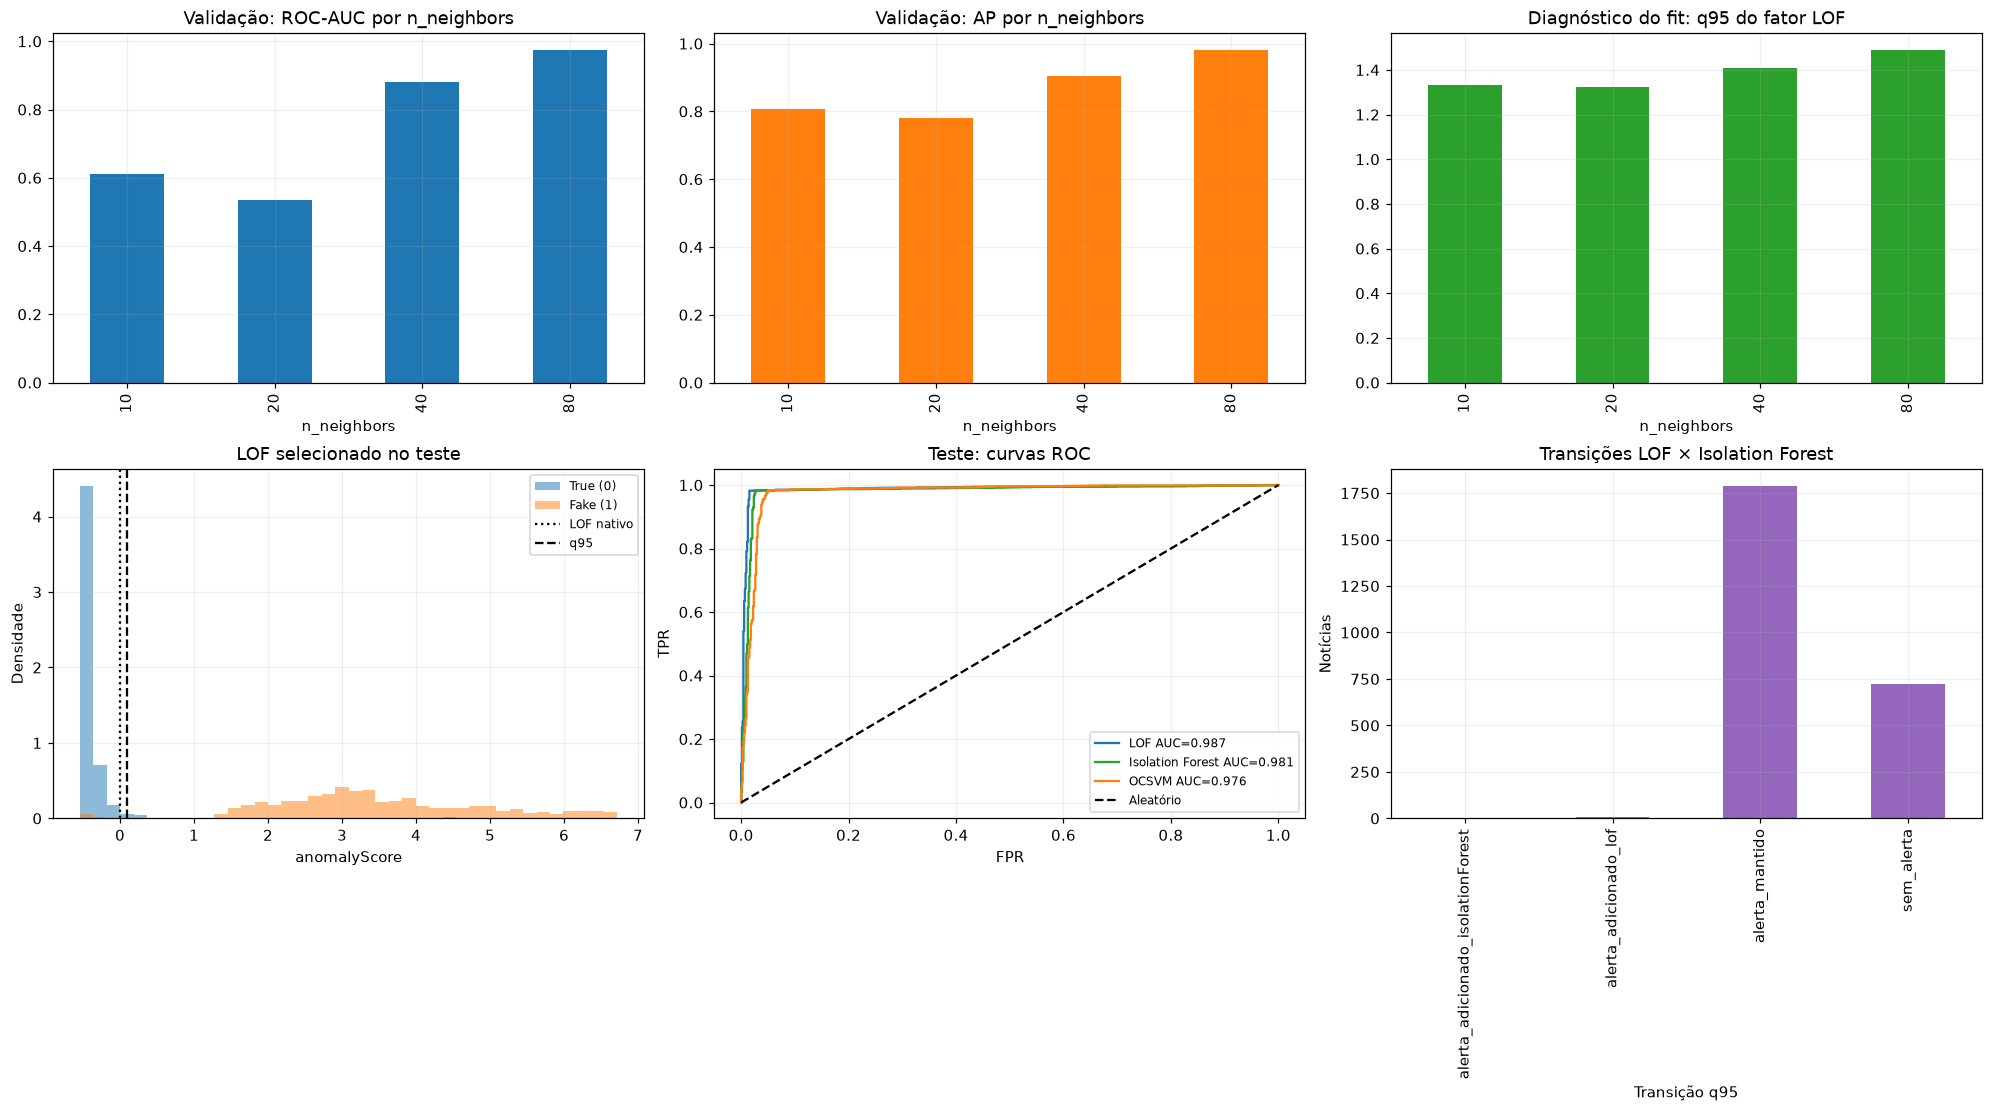

**5 True mais anômalas**

,id,label,partition,lofAnomalyScore,lofNativeIsAnomaly,lofQ95IsAnomaly,tem_autor,typeTokenRatio,linkDensity,punctuationDensity,uppercaseRatio,diversidade
0,365t,0,normalTest,5.316613,True,True,0,0.654545,0.0,0.181818,0.000000,0.800000
1,265t,0,normalTest,4.506789,True,True,0,0.705882,0.0,0.098039,0.021739,0.782609
2,286t,0,normalTest,4.364627,True,True,0,0.683333,0.0,0.166667,0.020000,0.820000
3,206t,0,normalTest,3.198024,True,True,0,0.649123,0.0,0.175439,0.042553,0.787234
4,269t,0,normalTest,2.941875,True,True,0,0.678571,0.0,0.196429,0.044444,0.844444


**5 Fake mais anômalas**

,id,label,partition,lofAnomalyScore,lofNativeIsAnomaly,lofQ95IsAnomaly,tem_autor,typeTokenRatio,linkDensity,punctuationDensity,uppercaseRatio,diversidade
0,3341,1,fakeTest,6.717459,True,True,0,0.690909,0.0,0.145455,0.0,0.808511
1,569,1,fakeTest,6.717459,True,True,0,0.690909,0.0,0.145455,0.0,0.808511
2,1937,1,fakeTest,6.715958,True,True,0,0.693548,0.0,0.145161,0.0,0.811321
3,1368,1,fakeTest,6.708444,True,True,0,0.685185,0.0,0.148148,0.0,0.804348
4,427,1,fakeTest,6.708444,True,True,0,0.685185,0.0,0.148148,0.0,0.804348


**5 Fake menos anômalas**

,id,label,partition,lofAnomalyScore,lofNativeIsAnomaly,lofQ95IsAnomaly,tem_autor,typeTokenRatio,linkDensity,punctuationDensity,uppercaseRatio,diversidade
0,38,1,fakeTest,-0.528835,False,False,1,0.690909,0.0,0.145455,0.000000,0.808511
1,19,1,fakeTest,-0.513361,False,False,1,0.764706,0.0,0.117647,0.000000,0.866667
2,1,1,fakeTest,-0.511970,False,False,1,0.683333,0.0,0.133333,0.019231,0.788462
3,26,1,fakeTest,-0.511010,False,False,1,0.706897,0.0,0.137931,0.000000,0.820000
4,67,1,fakeTest,-0.510018,False,False,1,0.714286,0.0,0.142857,0.000000,0.833333


**lofVsIsolationForest: maiores discordâncias de rank**

,id,label,lofAnomalyScore,isolationForestAnomalyScore,lofQ95IsAnomaly,lofNativeIsAnomaly,absoluteRankDifference,lofRank,controlRank,tem_autor,typeTokenRatio,linkDensity,punctuationDensity,uppercaseRatio,diversidade
0,1005,1,1.373875,0.252990,True,True,1771.0,1776.0,5.0,0,0.445946,0.0,0.283784,0.056604,0.622642
1,411,1,1.450361,0.249528,True,True,1757.0,1763.0,6.0,0,0.527273,0.0,0.163636,0.173913,0.630435
2,2341,1,1.427245,0.241157,True,True,1755.0,1767.0,12.0,0,0.477612,0.0,0.223881,0.076923,0.615385
3,2450,1,1.450588,0.231504,True,True,1739.0,1762.0,23.0,0,0.452830,0.0,0.169811,0.045455,0.545455
4,1197,1,1.516274,0.238800,True,True,1738.0,1752.0,14.0,0,0.549296,0.0,0.338028,0.085106,0.829787


**lofVsOcsvm: maiores discordâncias de rank**

,id,label,lofAnomalyScore,ocsvmAnomalyScore,lofQ95IsAnomaly,lofNativeIsAnomaly,absoluteRankDifference,lofRank,controlRank,tem_autor,typeTokenRatio,linkDensity,punctuationDensity,uppercaseRatio,diversidade
0,1005,1,1.373875,22.666645,True,True,1759.0,1776.0,17.0,0,0.445946,0.0,0.283784,0.056604,0.622642
1,411,1,1.450361,22.941375,True,True,1753.0,1763.0,10.0,0,0.527273,0.0,0.163636,0.173913,0.630435
2,1394,1,1.375809,22.227215,True,True,1746.0,1775.0,29.0,0,0.593220,0.0,0.237288,0.133333,0.777778
3,2648,1,1.445299,22.635981,True,True,1746.0,1765.0,19.0,0,0.636364,0.0,0.163636,0.173913,0.760870
4,2450,1,1.450588,22.777089,True,True,1746.0,1762.0,16.0,0,0.452830,0.0,0.169811,0.045455,0.545455


In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
validation_results_frame.plot(
    x="n_neighbors", y="validationRocAuc", kind="bar", ax=axes[0, 0],
    title="Validação: ROC-AUC por n_neighbors", legend=False, color="tab:blue",
)
validation_results_frame.plot(
    x="n_neighbors", y="validationAveragePrecision", kind="bar", ax=axes[0, 1],
    title="Validação: AP por n_neighbors", legend=False, color="tab:orange",
)
validation_results_frame["fitLofFactorQ95"] = validation_results_frame["fitDiagnostics"].map(
    lambda diagnostics: diagnostics["fitLofFactor"]["q95"]
)
validation_results_frame.plot(
    x="n_neighbors", y="fitLofFactorQ95", kind="bar", ax=axes[0, 2],
    title="Diagnóstico do fit: q95 do fator LOF", legend=False, color="tab:green",
)

selected_true_scores = test_predictions_frame.loc[
    test_predictions_frame["label"].eq(0), "lofAnomalyScore"
]
selected_fake_scores = test_predictions_frame.loc[
    test_predictions_frame["label"].eq(1), "lofAnomalyScore"
]
score_bins = np.histogram_bin_edges(
    np.concatenate([selected_true_scores, selected_fake_scores]), bins=40,
)
for values, name, color in [
    (selected_true_scores, "True (0)", "tab:blue"),
    (selected_fake_scores, "Fake (1)", "tab:orange"),
]:
    axes[1, 0].hist(values, bins=score_bins, density=True, alpha=0.5, label=name, color=color)
axes[1, 0].axvline(0, color="black", linestyle=":", label="LOF nativo")
axes[1, 0].axvline(selected_q95_threshold, color="black", linestyle="--", label="q95")
axes[1, 0].set(title="LOF selecionado no teste", xlabel="anomalyScore", ylabel="Densidade")
axes[1, 0].legend(fontsize=8)

for score_column, name, color in [
    ("lofAnomalyScore", "LOF", "tab:blue"),
    ("isolationForestAnomalyScore", "Isolation Forest", "tab:green"),
    ("ocsvmAnomalyScore", "OCSVM", "tab:orange"),
]:
    curve_labels = test_predictions_frame["label"].to_numpy(dtype=int)
    curve_scores = test_predictions_frame[score_column].to_numpy(dtype=float)
    curve_fpr, curve_tpr, _ = roc_curve(curve_labels, curve_scores)
    axes[1, 1].plot(
        curve_fpr, curve_tpr,
        label=f"{name} AUC={roc_auc_score(curve_labels, curve_scores):.3f}",
        color=color,
    )
axes[1, 1].plot([0, 1], [0, 1], "k--", label="Aleatório")
axes[1, 1].set(title="Teste: curvas ROC", xlabel="FPR", ylabel="TPR")
axes[1, 1].legend(fontsize=8)

transition_plot = transitions_frame.assign(
    modelPair=transitions_frame["lofVsIsolationForest"]
).groupby("modelPair").size()
transition_plot.plot(kind="bar", ax=axes[1, 2], color="tab:purple", title="Transições LOF × Isolation Forest")
axes[1, 2].set_xlabel("Transição q95")
axes[1, 2].set_ylabel("Notícias")
plt.show()

for title, records in [
    ("5 True mais anômalas", true_most_anomalous),
    ("5 Fake mais anômalas", fake_most_anomalous),
    ("5 Fake menos anômalas", fake_least_anomalous),
]:
    display(Markdown(f"**{title}**"))
    display(pd.DataFrame(records))
for title, records in rank_discordance_results.items():
    display(Markdown(f"**{title}: maiores discordâncias de rank**"))
    display(pd.DataFrame(records))


## 13. Conclusão calculada e artefatos

Quando `LOCAL_OUTLIER_FACTOR_OUTPUT_DIR` existe, esta célula salva JSONs estritos, CSVs por
ID e um relatório textual na pasta nova do run. Sem a variável, o notebook permanece
interativo e não grava evidências experimentais. O notebook-fonte nunca recebe outputs.


In [19]:
manifest = {
    "experimentKey": EXPERIMENT_KEY,
    "baseNotebookSha256": BASE_NOTEBOOK_SHA256,
    "ocsvmNotebookSha256": OCSVM_NOTEBOOK_SHA256,
    "sourceNotebookSha256": None,
    "corpusRevision": CORPUS_REVISION,
    "archiveSha256": hashlib.sha256(archive_path.read_bytes()).hexdigest(),
    "seed": RANDOM_STATE,
    "labels": {"0": "True", "1": "Fake"},
    "characterLimit": CHARACTER_LIMIT,
    "normalization": ["NFKC", "remove-leading-BOM"],
    "features": anomaly_columns,
    "num_palavrasRole": "extraction-and-audit-only",
    "partitionCounts": {name: int(len(frame)) for name, frame in partitions.items()},
    "candidates": {
        key: {
            "n_neighbors": int(value), "algorithm": "auto", "metric": "minkowski",
            "p": 2, "contamination": "auto", "novelty": True, "n_jobs": 1,
        }
        for key, value in LOF_CANDIDATES.items()
    },
    "selectedModelKey": selected_model_key,
    "selectionRule": "validation ROC-AUC, then AP within 1e-12, then lower n_neighbors",
    "selectionUsesFakeValidationLabels": True,
    "testWasNotUsedForSelection": True,
    "q95Source": "normalValidation anomalyScore only",
    "controls": {
        "isolationForest": {
            "n_estimators": 300, "contamination": "auto", "random_state": RANDOM_STATE,
            "n_jobs": -1, "standardScaler": False,
        },
        "oneClassSvm": {"kernel": "rbf", "gamma": "scale", "nu": 0.10},
    },
    "colabStatus": "não testado no Colab",
}
source_notebook_path = project_folder / "anomaly-detection-local-outlier-factor.ipynb"
if source_notebook_path.exists():
    manifest["sourceNotebookSha256"] = hashlib.sha256(source_notebook_path.read_bytes()).hexdigest()

output_directory = os.environ.get("LOCAL_OUTLIER_FACTOR_OUTPUT_DIR")
run_id = os.environ.get("LOCAL_OUTLIER_FACTOR_RUN_ID")
if output_directory:
    output_path = Path(output_directory)
    output_path.mkdir(parents=True, exist_ok=False) if not output_path.exists() else None
    manifest["runId"] = run_id
    write_json(output_path / "manifest.json", manifest)
    write_json(output_path / "validation-results.json", validation_records)
    write_json(output_path / "test-results.json", test_results)
    test_predictions_frame.to_csv(output_path / "test-predictions.csv", index=False)
    transitions_frame.to_csv(output_path / "transitions.csv", index=False)
    report = f"""# Resultado do run Local Outlier Factor

Run: `{run_id}`

- Candidato congelado: `{selected_model_key}`.
- Validação ROC-AUC: `{selected_validation_record['validationRocAuc']:.12f}`.
- Validação AP: `{selected_validation_record['validationAveragePrecision']:.12f}`.
- Teste LOF q95 ROC-AUC/AP: `{lof_q95_metrics['rocAuc']:.12f}` / `{lof_q95_metrics['averagePrecision']:.12f}`.
- Teste LOF q95 TP/FP/TN/FN: `{lof_q95_metrics['tp']}/{lof_q95_metrics['fp']}/{lof_q95_metrics['tn']}/{lof_q95_metrics['fn']}`.
- Teste LOF nativo TP/FP/TN/FN: `{lof_native_metrics['tp']}/{lof_native_metrics['fp']}/{lof_native_metrics['tn']}/{lof_native_metrics['fn']}`.
- Isolation Forest q95 TP/FP/TN/FN: `{isolation_forest_q95_metrics['tp']}/{isolation_forest_q95_metrics['fp']}/{isolation_forest_q95_metrics['tn']}/{isolation_forest_q95_metrics['fn']}`.
- OCSVM q95 TP/FP/TN/FN: `{ocsvm_q95_metrics['tp']}/{ocsvm_q95_metrics['fp']}/{ocsvm_q95_metrics['tn']}/{ocsvm_q95_metrics['fn']}`.

Os scores são sinais de desvio linguístico, não probabilidades de falsidade. A seleção foi
assistida por Fake-validation; o teste é histórico e já foi consultado; o texto foi truncado em
300 caracteres; o split não é temático. **não testado no Colab**.
"""
    (output_path / "run-report.md").write_text(report, encoding="utf-8")

display(Markdown(f"""
O candidato congelado foi **{selected_model_key}**, com ROC-AUC de validação
**{selected_validation_record['validationRocAuc']:.4f}** e AP **{selected_validation_record['validationAveragePrecision']:.4f}**.
No teste histórico, LOF q95 obteve ROC-AUC **{lof_q95_metrics['rocAuc']:.4f}**, AP
**{lof_q95_metrics['averagePrecision']:.4f}**, recall **{lof_q95_metrics['recall']:.2%}** e FPR
**{lof_q95_metrics['fpr']:.2%}**. Estes números descrevem desvio linguístico neste split;
não provam falsidade nem superioridade estatística.

O ajuste usou **{len(normal_train_frame)} True e nenhuma Fake**, com até **{CHARACTER_LIMIT}**
caracteres e seis features. A seleção usou labels Fake somente na validação. O teste histórico
já foi consultado, o split não é temático e **não testado no Colab**.
"""))



O candidato congelado foi **lof_neighbors_080**, com ROC-AUC de validação
**0.9747** e AP **0.9812**.
No teste histórico, LOF q95 obteve ROC-AUC **0.9874**, AP
**0.9939**, recall **98.28%** e FPR
**3.61%**. Estes números descrevem desvio linguístico neste split;
não provam falsidade nem superioridade estatística.

O ajuste usou **2160 True e nenhuma Fake**, com até **300**
caracteres e seis features. A seleção usou labels Fake somente na validação. O teste histórico
já foi consultado, o split não é temático e **não testado no Colab**.
